# Speech Recognition with Neural Networks: Utterance to Phoneme Mapping


# Installs

In [1]:
!pip install torchinfo --quiet
!pip install python-Levenshtein --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.6 MB/s eta 0:00:00


## Imports

In [2]:
import torch
import random
import numpy as np
import pandas as pd

import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import wandb
import torchaudio.transforms as tat
from torchaudio.models.decoder import cuda_ctc_decoder
import Levenshtein

from sklearn.metrics import accuracy_score
import gc

import glob

import zipfile
from tqdm.auto import tqdm
import os
import datetime


import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

Device:  cuda


In [3]:
# Check if data available:
print(os.listdir("/kaggle/input"))

['hw-3-p-2-automatic-speech-recognition-asr-11-785', '11785-hw3p2-1']


# Config

In [ ]:
%%writefile config.yaml

# Subset of dataset to use (1.0 == 100% of data)
subset: 1.0
learning_rate: 0.001

epochs: 80

train_beam_width: 5
test_beam_width: 10
mfcc_features: 28 # DO NOT MODIFY

# Set embedding size (the dimensionality of the LSTM hidden state)
embed_size: 128   # {64,128,256} Try out higher embed_size if you have powerfull GPU(RAM) other than T4

batch_size: 350 # Increase if your device can handle it

encoder dropout: 0.5
lstm dropout: 0.5
decoder dropout: 0.5
wandb: True

Name: "Chia Hui Yen"

Writing config.yaml


In [5]:
import yaml
with open("config.yaml") as file:
    config = yaml.safe_load(file)

In [6]:
config

{'subset': 1.0,
 'learning_rate': 0.001,
 'epochs': 80,
 'train_beam_width': 5,
 'test_beam_width': 10,
 'mfcc_features': 28,
 'embed_size': 128,
 'batch_size': 350,
 'encoder dropout': 0.5,
 'lstm dropout': 0.5,
 'decoder dropout': 0.5,
 'wandb': True,
 'Name': 'Chia Hui Yen'}

In [7]:
BATCH_SIZE = config["batch_size"] # Define batch size from config
ROOT = "/kaggle/input/hw-3-p-2-automatic-speech-recognition-asr-11-785/11785-S25-hw3p2" # Specify the directory to your root based on your environment

# Setup Vocabulary (DO NOT MODIFY)

In [8]:
# ARPABET PHONEME MAPPING
# DO NOT CHANGE

CMUdict_ARPAbet = {
    "" : " ",
    "[SIL]": "-", "NG": "G", "F" : "f", "M" : "m", "AE": "@",
    "R"    : "r", "UW": "u", "N" : "n", "IY": "i", "AW": "W",
    "V"    : "v", "UH": "U", "OW": "o", "AA": "a", "ER": "R",
    "HH"   : "h", "Z" :
     "z", "K" : "k", "CH": "C", "W" : "w",
    "EY"   : "e", "ZH": "Z", "T" : "t", "EH": "E", "Y" : "y",
    "AH"   : "A", "B" : "b", "P" : "p", "TH": "T", "DH": "D",
    "AO"   : "c", "G" : "g", "L" : "l", "JH": "j", "OY": "O",
    "SH"   : "S", "D" : "d", "AY": "Y", "S" : "s", "IH": "I",
    "[SOS]": "[SOS]", "[EOS]": "[EOS]"
}


CMUdict = list(CMUdict_ARPAbet.keys())
ARPAbet = list(CMUdict_ARPAbet.values())

PHONEMES = CMUdict[:-2] #To be used for mapping original transcripts to integer indices
LABELS = ARPAbet[:-2] #To be used for mapping predictions to strings

OUT_SIZE = len(PHONEMES) # Number of output classes
print("Number of Phonemes:", OUT_SIZE)

# Indexes of BLANK and SIL phonemes
BLANK_IDX=CMUdict.index('')
SIL_IDX=CMUdict.index('[SIL]')

print("Index of Blank:", BLANK_IDX)
print("Index of [SIL]:", SIL_IDX)

Number of Phonemes: 41
Index of Blank: 0
Index of [SIL]: 1


### Sample data inspection & sanity check

In [9]:
test_mfcc = f"{ROOT}/train-clean-100/mfcc/103-1240-0000.npy"
test_transcript = f"{ROOT}/train-clean-100/transcript/103-1240-0000.npy"

mfcc = np.load(test_mfcc)
transcript = np.load(test_transcript)[1:-1] #Removed [SOS] and [EOS]

print("MFCC Shape:", mfcc.shape)
print("Number of MFCCs:", mfcc.shape[1])
print("\nMFCC:\n", mfcc)
print("\nTranscript shape:", transcript.shape)

print("\nOriginal Transcript:\n", transcript)

# map the loaded transcript (from phonemes representation) to corresponding labels representation
mapped_transcript = [CMUdict_ARPAbet[k] for k in transcript]
print("\nTranscript mapped from PHONEMES representation to LABELS representation:\n", mapped_transcript)

# Mapping list of PHONEMES to list of Integer indexes
map = {k: i for i, k in enumerate(PHONEMES)}
print("\nMapping list of PHONEMES to list of Integer indexes:\n", map)



MFCC Shape: (1404, 28)
Number of MFCCs: 28

MFCC:
 [[ 1.10582151e+01  1.28330450e+01  2.10689220e+01 ... -8.75406042e-02
   7.30623007e-02  9.48924713e+01]
 [ 1.16850815e+01  1.38329487e+01  2.19087906e+01 ... -1.39180899e-01
  -6.15991093e-02  9.55670319e+01]
 [ 1.11048431e+01  1.67276516e+01  2.28863831e+01 ... -4.03698802e-01
   8.09250996e-02  9.54314651e+01]
 ...
 [ 2.62413955e+00 -1.26996317e+01  2.79472313e+01 ... -1.49060452e+00
  -2.67574161e-01  1.16191261e+02]
 [ 3.05713993e-02 -1.20763254e+01  2.60116520e+01 ... -8.54688883e-01
  -1.20284989e-01  1.17127373e+02]
 [-1.33604801e+00 -1.17101593e+01  2.44703121e+01 ... -9.30283189e-01
  -8.16672146e-02  1.18280014e+02]]

Transcript shape: (145,)

Original Transcript:
 ['[SIL]' 'CH' 'AE' 'P' 'T' 'ER' 'W' 'AH' 'N' '[SIL]' 'M' 'IH' 'S' 'IH' 'Z'
 'R' 'EY' 'CH' 'AH' 'L' 'IH' 'N' 'D' 'IH' 'Z' 'S' 'ER' 'P' 'R' 'AY' 'Z'
 'D' '[SIL]' 'M' 'IH' 'S' 'IH' 'Z' 'R' 'EY' 'CH' 'AH' 'L' 'IH' 'N' 'D'
 '[SIL]' 'L' 'AY' 'V' 'D' '[SIL]' 'JH' 'AH' 'S

# Dataset and Dataloader

### Train Data

In [10]:
from torchaudio.transforms import TimeMasking, FrequencyMasking

In [ ]:
class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, root, phonemes=PHONEMES, partition="train-clean-100", isAug=False, preload=False):
        self.PHONEMES = phonemes
        self.mfcc_dir = os.path.join(root, partition, 'mfcc')
        self.transcript_dir = os.path.join(root, partition, 'transcript')
        
        self.mfcc_files = sorted(os.listdir(self.mfcc_dir))
        self.transcript_files = sorted(os.listdir(self.transcript_dir))
        
        subset_size = int(config['subset'] * len(self.mfcc_files))
        self.mfcc_files = self.mfcc_files[:subset_size]
        self.transcript_files = self.transcript_files[:subset_size]
        self.isAug = isAug
        
        assert len(self.mfcc_files) == len(self.transcript_files), "MFCC和转录文件数量不匹配"
        
        # 可选的预加载
        self.preloaded = preload
        if self.preloaded:
            print(f"预加载{len(self.mfcc_files)}个文件...")
            self.mfccs = []
            self.transcripts = []
            for i in tqdm(range(len(self.mfcc_files))):
                mfcc_path = os.path.join(self.mfcc_dir, self.mfcc_files[i])
                transcript_path = os.path.join(self.transcript_dir, self.transcript_files[i])
                
                mfcc = np.load(mfcc_path)
                mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-8)
                self.mfccs.append(mfcc)
                
                try:
                    transcript = np.load(transcript_path)
                    if len(transcript) > 0 and transcript[0] == '[SOS]' and transcript[-1] == '[EOS]':
                        transcript = transcript[1:-1]
                    
                    transcript_indices = [self.PHONEMES.index(p) for p in transcript]
                    self.transcripts.append(np.array(transcript_indices, dtype=np.int64))
                except Exception as e:
                    print(f"处理文件{transcript_path}时出错: {e}")
                    raise
    
    def __len__(self):
        return len(self.mfcc_files)
    
    def __getitem__(self, idx):
        if self.preloaded:
            mfcc = self.mfccs[idx]
            transcript = self.transcripts[idx]
        else:
            mfcc_path = os.path.join(self.mfcc_dir, self.mfcc_files[idx])
            transcript_path = os.path.join(self.transcript_dir, self.transcript_files[idx])
            
            mfcc = np.load(mfcc_path)
            mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-8) # normalize mfcc
            
            transcript = np.load(transcript_path)
            if len(transcript) > 0 and transcript[0] == '[SOS]' and transcript[-1] == '[EOS]':
                transcript = transcript[1:-1]  # remove SOS and EOS tokens
            
            try:
                transcript_indices = [self.PHONEMES.index(p) for p in transcript]
                transcript = np.array(transcript_indices, dtype=np.int64)
            except ValueError as e:
                print(f"错误发生在文件 {transcript_path}: {e}")
                print(f"转录内容: {transcript}")
                raise
        
        # change to tensor
        mfcc = torch.tensor(mfcc, dtype=torch.float32)
        transcript = torch.tensor(transcript, dtype=torch.int64)
        
        return mfcc, transcript
    
    def collate_fn(self, batch):
        # get feature and tag
        batch_mfcc = [item[0] for item in batch]
        batch_transcript = [item[1] for item in batch]
        
        # get length of each mfcc and tags
        lengths_mfcc = [len(mfcc) for mfcc in batch_mfcc]
        lengths_transcript = [len(transcript) for transcript in batch_transcript]
        
        # pad
        batch_mfcc_pad = pad_sequence(batch_mfcc, batch_first=True, padding_value=0.0)
        batch_transcript_pad = pad_sequence(batch_transcript, batch_first=True, padding_value=-1)
        
        if self.isAug:
            # data augment
            batch_mfcc_pad = batch_mfcc_pad.permute(0, 2, 1)  # [batch, freq, time]
            time_mask = TimeMasking(time_mask_param=10)
            freq_mask = FrequencyMasking(freq_mask_param=5)
            for i in range(batch_mfcc_pad.size(0)):
                batch_mfcc_pad[i] = time_mask(batch_mfcc_pad[i])
                batch_mfcc_pad[i] = freq_mask(batch_mfcc_pad[i])
            batch_mfcc_pad = batch_mfcc_pad.permute(0, 2, 1)  # Back to [batch, time, freq]
        
        return batch_mfcc_pad, batch_transcript_pad, torch.tensor(lengths_mfcc), torch.tensor(lengths_transcript)

In [ ]:
class AudioDatasetTest(torch.utils.data.Dataset):
    def __init__(self, root, phonemes=PHONEMES, partition="test-clean", preload=False):
        self.PHONEMES = phonemes
        self.mfcc_dir = os.path.join(root, partition, 'mfcc')
        
        self.mfcc_files = sorted(os.listdir(self.mfcc_dir))
        
        self.preloaded = preload
        if self.preloaded:
            print(f"preload{len(self.mfcc_files)}test files...")
            self.mfccs = []
            for i in tqdm(range(len(self.mfcc_files))):
                mfcc_path = os.path.join(self.mfcc_dir, self.mfcc_files[i])
                mfcc = np.load(mfcc_path)
                mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-8) 
                self.mfccs.append(mfcc)
    
    def __len__(self):
        return len(self.mfcc_files)
    
    def __getitem__(self, idx):
        if hasattr(self, 'preloaded') and self.preloaded:
            mfcc = self.mfccs[idx]
        else:
            mfcc_path = os.path.join(self.mfcc_dir, self.mfcc_files[idx])
            mfcc = np.load(mfcc_path)
            mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-8) 
        
        # Convert to tensor
        mfcc = torch.tensor(mfcc, dtype=torch.float32)
        
        return mfcc
    
    def collate_fn(self, batch):
        lengths_mfcc = [len(mfcc) for mfcc in batch]
        
        batch_mfcc_pad = pad_sequence(batch, batch_first=True, padding_value=0.0)
        
        return batch_mfcc_pad, torch.tensor(lengths_mfcc)

### Test Data

In [13]:
# To free up ram
import gc
gc.collect()

289

### Create Datasets & Data loaders

In [14]:
# Create objects for the dataset classes
train_data = AudioDataset(ROOT, partition="train-clean-100", isAug=True) # TODO: Fill in the required parameters
val_data = AudioDataset(ROOT, partition="dev-clean", isAug=False) # TODO: You can either use the same class for train data with some modifications or make a new one :)
test_data = AudioDatasetTest(ROOT, partition="test-clean") # TODO: Fill in the required parameters

In [15]:
# Check length
print(f"Train length: {len(train_data)}")
print(f"Val length: {len(val_data)}")
print(f"Test length: {len(test_data)}")

Train length: 28539
Val length: 2703
Test length: 2620


In [16]:
# Do NOT forget to pass in the collate function as an argument while creating the dataloader
# TODO
train_loader = torch.utils.data.DataLoader(
    dataset     = train_data,
    num_workers = 2,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = True,
    collate_fn = train_data.collate_fn,
)

val_loader = torch.utils.data.DataLoader(
    dataset     = val_data,
    num_workers = 2,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False,
    collate_fn  = val_data.collate_fn,
)

test_loader = torch.utils.data.DataLoader(
    dataset     = test_data,
    num_workers = 2,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False,
    collate_fn  = test_data.collate_fn,
)

print("Batch size: ", config['batch_size'])
print("Train dataset samples = {}, batches = {}".format(train_data.__len__(), len(train_loader)))
print("Val dataset samples = {}, batches = {}".format(val_data.__len__(), len(val_loader)))
print("Test dataset samples = {}, batches = {}".format(test_data.__len__(), len(test_loader)))

Batch size:  350
Train dataset samples = 28539, batches = 82
Val dataset samples = 2703, batches = 8
Test dataset samples = 2620, batches = 8


In [17]:
# sanity check
for data in train_loader:
    x, y, lx, ly = data
    print(x.shape, y.shape, lx.shape, ly.shape)
    break

# for data in test_loader:
#     x, lx = data  # Unpack the two returned items
#     print(x.shape, lx.shape)
#     break

torch.Size([350, 1716, 28]) torch.Size([350, 221]) torch.Size([350]) torch.Size([350])


# Visualize Data

Note: In the visualized graph, do not confuse padded regions of the MFCC sequences with time/freq augmentation masks. Remember all MFCCs were padded to the maximum sequence length

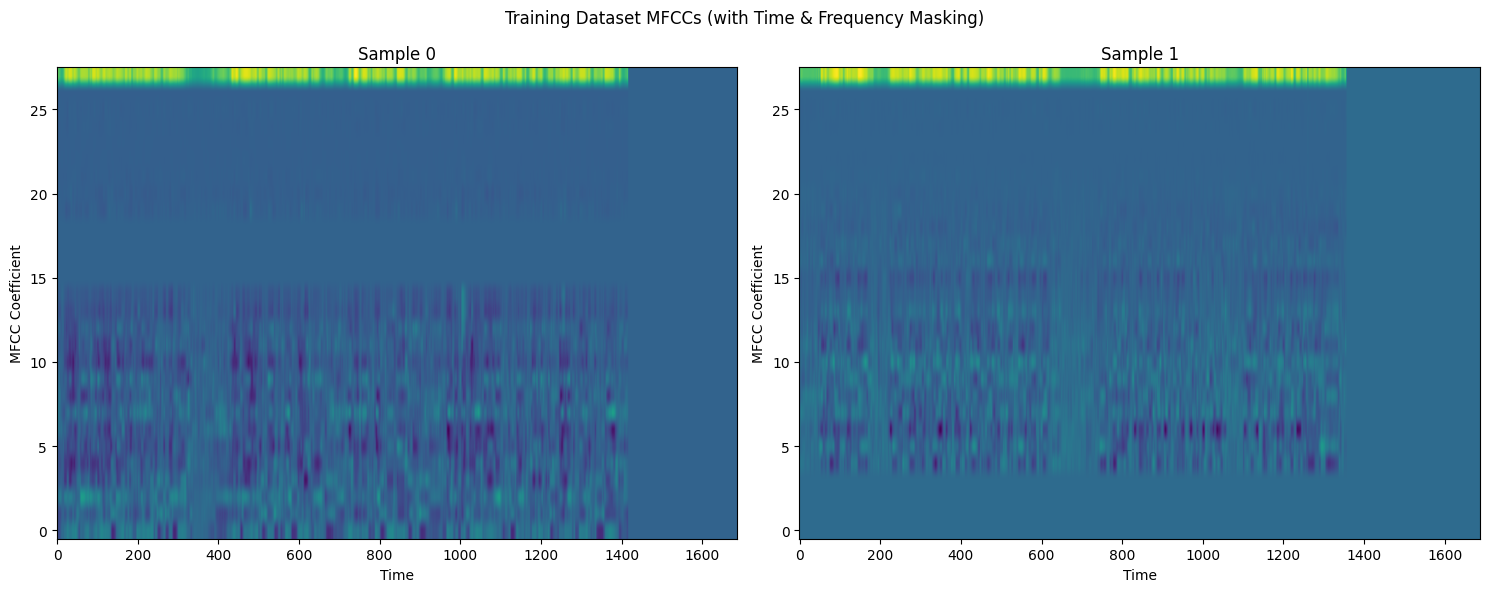

In [18]:
import matplotlib.pyplot as plt

def visualize_batch(loader, title="Dataset Visualization", num_samples=2):
    """
    Visualizes MFCC features from a single batch of data.

    Args:
        loader (DataLoader): DataLoader object (for train, val, or test).
        title (str): Title of the plot.
        num_samples (int): Number of samples to visualize from the batch.
    """
    # Get one batch from the loader.
    batch = next(iter(loader))

    # The collate_fn we defined in the dataset class returns a tuple, where the first element is the padded MFCC tensor.
    mfcc_batch = batch[0] if isinstance(batch, (tuple, list)) else batch

    # Limit to a few samples.
    num_samples = min(num_samples, mfcc_batch.size(0))

    # Create subplots.
    fig, axes = plt.subplots(1, num_samples, figsize=(15,6))
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        # Each MFCC tensor is of shape [time, frequency].
        # Transpose for visualization: time on x-axis, features on y-axis.
        mfcc_img = mfcc_batch[i].cpu().numpy().T
        im = axes[i].imshow(mfcc_img, origin="lower", aspect="auto", cmap="viridis")
        axes[i].set_title(f"Sample {i}")
        axes[i].set_xlabel("Time")
        axes[i].set_ylabel("MFCC Coefficient")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Visualize batches of data
visualize_batch(train_loader, title="Training Dataset MFCCs (with Time & Frequency Masking)")


# Network


## ASR Network
We define everything we need for the ASR model in separate classes, and put them all together in the end

#### Permute class

In [19]:
class Permute(torch.nn.Module):
    '''
    Used to transpose/permute the dimensions of an MFCC tensor.
    '''
    def forward(self, x):
        return x.transpose(1, 2)

#### Pyramidal Bi-LSTM (pBLSTM) class

In [ ]:
class pBLSTM(torch.nn.Module):

    '''
    Pyramidal BiLSTM
    Read the write up/paper and understand the concepts and then write your implementation here.

    At each step,
    1. Pad your input if it is packed (Unpack it)
    2. Reduce the input length dimension by concatenating feature dimension
        (Tip: Write down the shapes and understand)
        (i) How should  you deal with odd/even length input?
        (ii) How should you deal with input length array (x_lens) after truncating the input?
    3. Pack your input
    4. Pass it into LSTM layer

    To make our implementation modular, we pass 1 layer at a time.
    '''

    def __init__(self, input_size, hidden_size):
        super(pBLSTM, self).__init__()

        # construct by stacking LSTM ?
        # https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html
        # self.blstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, bidirectional=True, batch_first=True) # TODO: Initialize a single layer bidirectional LSTM with the given input_size and hidden_size
        # self.blstm = nn.LSTM(input_size= 2*input_size, hidden_size=hidden_size, bidirectional=True, batch_first=True)
        # self.blstm = nn.LSTM(input_size = 2*input_size, hidden_size = hidden_size, num_layers = 1,bidirectional = True, dropout = 0.2, batch_first = True)
        self.blstm = nn.LSTM(
            input_size=2*input_size,  # The input size to the LSTM needs to be doubled because we're concatenating adjacent time steps
            hidden_size=hidden_size,
            num_layers=1, 
            bidirectional=True, 
            dropout=0.2, 
            batch_first=True
        )
        
    def forward(self, x_packed): # x_packed is a PackedSequence
        #MYNOTE:
        """
        pad packed -> pack padded sequences:
        
        pack_padded_sequence:
        
        Purpose: "Packs" padded sequences to tell RNN which data is real and which is padding
        Goal: Improve computation efficiency by avoiding wasted resources on padding
        When to use: Before feeding into RNN
        
        pad_packed_sequence:
        
        Purpose: Converts packed sequences back to padded tensor format
        Goal: RNN outputs packed format but subsequent processing may need regular tensors
        When to use: After RNN computation
        
        Workflow:
        1. Use pad_sequence to pad sequences of different lengths to same length
        2. Use pack_padded_sequence before feeding to RNN (preserves original length info)
        3. After RNN, use pad_packed_sequence to convert result back to regular tensor
        """
        # TODO: Pad Packed Sequence
        # from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
        x, x_lens = pad_packed_sequence(x_packed, batch_first=True)

        # print(f"Before trunc_reshape - x shape: {x.shape}, min length: {x_lens.min()}, max length: {x_lens.max()}")

        # TODO: Call self.trunc_reshape() which downsamples the time steps of x and increases the feature dimensions as mentioned above
        # self.trunc_reshape will return 2 outputs. What are they? Think about what quantites are changing.
        # Downsample time steps
        x, x_lens = self.trunc_reshape(x, x_lens)

        # MAKE SURE x_lens on CPU, same as encoder forward
        x_lens_cpu = x_lens.cpu() if x_lens.is_cuda else x_lens
        # !! debug
        # print(f"After trunc_reshape - x shape: {x.shape}, min length: {x_lens.min()}, max length: {x_lens.max()}")
        if x_lens.min() == 0:
            print("WARNING: Found sequence with zero length after downsampling!")
        
        # TODO: Pack Padded Sequence. What output(s) would you get?
        x_packed = pack_padded_sequence(x, x_lens_cpu, batch_first=True, enforce_sorted=False)

        # TODO: Pass the sequence through bLSTM
        y_packed, _ = self.blstm(x_packed)

        return y_packed #TODO

    def trunc_reshape(self, x, x_lens):
        if x.shape[1]%2 != 0:
            x= x[:,:-1,:]

        x = x.reshape(x.shape[0],x.shape[1]//2, x.shape[2]*2)
        x_lens  = x_lens//2
        
        return x, x_lens

In [ ]:
# locked dropout, better 泛化
class LockedDropout(nn.Module):
    def __init__(self, dropout_rate):
        super(LockedDropout, self).__init__()
        self.dropout_rate = dropout_rate

    def forward(self, x):
        # Apply dropout only during training, not during testing phase
        if not self.training or self.dropout_rate == 0:
            return x
            
        # 解包序列（如果是PackedSequence）
        if isinstance(x, torch.nn.utils.rnn.PackedSequence):
            x, lengths = pad_packed_sequence(x, batch_first=True)
            packed = True
        else:
            packed = False
            
        # Time mask 对每个样本的每个特征通道只生成一个time mask, 但在时间维度上保持相同
        batch_size, seq_len, hidden_size = x.size()
        mask = x.new_ones(batch_size, 1, hidden_size)
        mask = F.dropout(mask, p=self.dropout_rate, training=True)
        
        # expand all the time step
        mask = mask.expand_as(x)
        
        # apply mask
        x = x * mask
        
        # 如果原来是PackedSequence，需要解包
        if packed:
            lengths_cpu = lengths.cpu() if lengths.is_cuda else lengths
            x = pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            
        return x

#### Util for LSTM


In [22]:
class LSTMWrapper(torch.nn.Module):
    '''
    Used to get only output of lstm, not the hidden states.
    '''
    def __init__(self, lstm):
        super(LSTMWrapper, self).__init__()
        self.lstm = lstm

    def forward(self, x):
        output, _ = self.lstm(x)
        return output

#### Encoder class

In [23]:
class Encoder(torch.nn.Module):
    '''
    The Encoder takes utterances as inputs and returns latent feature representations
    '''
    def __init__(self, input_size, encoder_hidden_size):
        super(Encoder, self).__init__()
        # The expansion dimensions for CNN layers
        self.expand_dim = [128, 256]
        # CNN feature extraction layers
        self.embedding = nn.Sequential(
            Permute(),  # [B, T, F] -> [B, F, T] 
            nn.Conv1d(input_size, self.expand_dim[0], kernel_size=3, padding=1),
            nn.BatchNorm1d(num_features=self.expand_dim[0]),
            nn.ReLU(),
            nn.Conv1d(self.expand_dim[0], self.expand_dim[1], kernel_size=3, padding=1),
            nn.BatchNorm1d(num_features=self.expand_dim[1]),
            Permute()  # [B, F, T] -> [B, T, F] 
        )
        
        # Bidirectional LSTM before pBLSTM layers
        self.blstm = nn.LSTM(
            input_size=self.expand_dim[1], 
            hidden_size=encoder_hidden_size, 
            num_layers=2, 
            bidirectional=True, 
            batch_first=True, 
            dropout=0.2
        )
        
        # Individual pBLSTM and dropout layers
        self.pBLSTM1 = pBLSTM(input_size=encoder_hidden_size*2, hidden_size=encoder_hidden_size)
        self.dropout1 = LockedDropout(0.4)
        self.pBLSTM2 = pBLSTM(input_size=encoder_hidden_size*2, hidden_size=encoder_hidden_size)
        self.dropout2 = LockedDropout(0.3)
        
    def forward(self, x, x_lens):
        #TODO: Call the embedding layer
        # Apply CNN embedding
        x = self.embedding(x)
        
        # Ensure lengths are on CPU
        x_lens_cpu = x_lens.cpu() if x_lens.is_cuda else x_lens
        # TODO: Pack Padded Sequence
        # TODO: Pass Sequence through the pyramidal Bi-LSTM layer
        # TODO: Pad Packed Sequence
        
        # Pack padded sequence for LSTM
        x_packed = pack_padded_sequence(x, x_lens_cpu, batch_first=True, enforce_sorted=False)
        
        # Pass through BiLSTM layers
        blstm_out, _ = self.blstm(x_packed)
        
        # Pass through first pBLSTM and dropout
        pblstm_out1 = self.pBLSTM1(blstm_out)
        pblstm_out1 = self.dropout1(pblstm_out1)
        
        # Pass through second pBLSTM and dropout
        pblstm_out2 = self.pBLSTM2(pblstm_out1)
        pblstm_out2 = self.dropout2(pblstm_out2)
        
        # Unpack sequence
        encoder_outputs, encoder_lens = pad_packed_sequence(pblstm_out2, batch_first=True)
        
        return encoder_outputs, encoder_lens

print('done')

done


#### Decoder class

In [24]:
class Decoder(torch.nn.Module):

    def __init__(self, embed_size, output_size= 41):
        super().__init__()
        
        self.mlp = torch.nn.Sequential(
            # is permute a linear?
            Permute(), torch.nn.BatchNorm1d(embed_size), Permute(),
            #TODO define your MLP arch. Refer HW1P2
            #Use Permute Block before and after BatchNorm1d() to match the size
            nn.Linear(embed_size, 2048),
            nn.GELU(),
            Permute(), torch.nn.BatchNorm1d(2048), Permute(),
            nn.Dropout(0.2),
            nn.Linear(2048, 1024),
            nn.GELU(),
            Permute(), torch.nn.BatchNorm1d(1024), Permute(),
            nn.Dropout(0.2),
            nn.Linear(1024, output_size)

            #TODO define your MLP arch. Refer HW1P2
            #Use Permute Block before and after BatchNorm1d() to match the size
            #Now you can stack your MLP layers
        )

        self.softmax = torch.nn.LogSoftmax(dim=2)


    def forward(self, encoder_out):

        #TODO: Call your MLP
        #TODO: Think about what should be the final output of the decoder for classification
        out = self.mlp(encoder_out)
        out = self.softmax(out)

        return out

print('done')

done


#### ASR Model Class

In [25]:
class ASRModel(torch.nn.Module):

    def __init__(self, input_size, embed_size=config['embed_size'], output_size= len(PHONEMES)):
        # embed_size= 192 might be a good choice?
        super().__init__()

        # Initialize encoder and decoder
        """
        self.encoder        = Encoder(X) # TODO: Initialize Encoder
        self.decoder        = Decoder(E) # TODO: Initialize Decoder
        """

        self.encoder        = Encoder(input_size, embed_size) # TODO: Initialize Encoder
        self.decoder        = Decoder(embed_size*2, output_size) # TODO: Initialize Decoder


    def forward(self, x, lengths_x):

        encoder_out, encoder_lens   = self.encoder(x, lengths_x)
        # print(f"Encoder output shape: {encoder_out.shape}")
        decoder_out                 = self.decoder(encoder_out)

        return decoder_out, encoder_lens

## Initialize ASR Network

In [26]:
torch.cuda.empty_cache()

In [27]:
model = ASRModel(
    input_size  = 28,  #TODO, 28 => mfcc features
    embed_size  = config['embed_size'], #TODO
    # embed_size  = 128, #TODO
    output_size = len(PHONEMES)
).to(device)
print(model)

print("embed_size:", config['embed_size'], "output_size:", len(PHONEMES))

ASRModel(
  (encoder): Encoder(
    (embedding): Sequential(
      (0): Permute()
      (1): Conv1d(28, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
      (4): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): Permute()
    )
    (blstm): LSTM(256, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
    (pBLSTM1): pBLSTM(
      (blstm): LSTM(512, 128, batch_first=True, dropout=0.2, bidirectional=True)
    )
    (dropout1): LockedDropout()
    (pBLSTM2): pBLSTM(
      (blstm): LSTM(512, 128, batch_first=True, dropout=0.2, bidirectional=True)
    )
    (dropout2): LockedDropout()
  )
  (decoder): Decoder(
    (mlp): Sequential(
      (0): Permute()
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [28]:
torch.cuda.empty_cache()
gc.collect()

7082

In [29]:
summary(model, input_data=[x.to(device), lx.to(device)])

Layer (type:depth-idx)                   Output Shape              Param #
ASRModel                                 [350, 429, 41]            --
├─Encoder: 1-1                           [350, 429, 256]           --
│    └─Sequential: 2-1                   [350, 1716, 256]          --
│    │    └─Permute: 3-1                 [350, 28, 1716]           --
│    │    └─Conv1d: 3-2                  [350, 128, 1716]          10,880
│    │    └─BatchNorm1d: 3-3             [350, 128, 1716]          256
│    │    └─ReLU: 3-4                    [350, 128, 1716]          --
│    │    └─Conv1d: 3-5                  [350, 256, 1716]          98,560
│    │    └─BatchNorm1d: 3-6             [350, 256, 1716]          512
│    │    └─Permute: 3-7                 [350, 1716, 256]          --
│    └─LSTM: 2-2                         [432614, 256]             790,528
│    └─pBLSTM: 2-3                       [216228, 256]             --
│    │    └─LSTM: 3-8                    [216228, 256]             657

# Training Config
Initialize Loss Criterion, Optimizer, CTC Beam Decoder, Scheduler, Scaler (Mixed-Precision), etc

In [30]:
# TODO: Define CTC loss as the criterion. How would the losses be reduced?
criterion = nn.CTCLoss(blank=BLANK_IDX, reduction='mean') #TODO
# CTC Loss: https://pytorch.org/docs/stable/generated/torch.nn.CTCLoss.html
# Refer to the handout for hints

# ???
# Initialize random batch of input vectors, for *size = (T,N,C)
"""
input = torch.randn(T, N, C).log_softmax(2).detach().requires_grad_()

# Initialize random batch of targets (0 = blank, 1:C = classes)
target = torch.randint(low=1, high=C, size=(N, S), dtype=torch.long)

input_lengths = torch.full(size=(N,), fill_value=T, dtype=torch.long)
target_lengths = torch.randint(low=S_min, high=S, size=(N,), dtype=torch.long)
ctc_loss = nn.CTCLoss()
loss = ctc_loss(input, target, input_lengths, target_lengths)
loss.backward()
"""

optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate']) #TODO: What goes in here?

# TODO: Declare the decoder. Use the PyTorch Cuda CTC Decoder to decode phonemes
# CTC Decoder: https://pytorch.org/audio/2.1/generated/torchaudio.models.decoder.cuda_ctc_decoder.html
decoder = cuda_ctc_decoder(tokens=LABELS, nbest=1, beam_size=config['train_beam_width']) #TODO

# TODO:
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer,
                                    max_lr = config['learning_rate'],
                                    steps_per_epoch=len(train_loader),
                                    epochs=config["epochs"],
                                    pct_start=0.01)

# Mixed Precision, if you need it
scaler = torch.cuda.amp.GradScaler()

### Decode Prediction

In [31]:
def decode_prediction(output, output_lens, decoder, PHONEME_MAP = LABELS):
    # Look at docs for CUDA_CTC_DECODER for more info on how it was used here:
    # https://pytorch.org/audio/main/tutorials/asr_inference_with_cuda_ctc_decoder_tutorial.html
    output = output.contiguous()
    output_lens = output_lens.to(output.device).to(torch.int32).contiguous()
    beam_results = decoder(output, output_lens.to(torch.int32))
    
    pred_strings = []
    
    for i in range(len(beam_results)):
        # Get the top beam (index 0) for this sample and its token sequence
        top_beam_results = beam_results[i][0].tokens
        # Map indices to phoneme labels and join them into a space-separated string
        pred_string = ''.join([PHONEME_MAP[idx] for idx in top_beam_results])
        pred_strings.append(pred_string)

    return pred_strings

def calculate_levenshtein(output, label, output_lens, label_lens, decoder, PHONEME_MAP= LABELS): # y - sequence of integers
    dist            = 0
    batch_size      = label.shape[0]
    
    pred_strings    = decode_prediction(output, output_lens, decoder, PHONEME_MAP)
    
    for i in range(batch_size):
        # TODO: Get predicted string and label string for each element in the batch
        # check the shape of label !! calc method
        label_indices = label[i, :label_lens[i]].cpu().numpy()
        label_string = ''.join([PHONEME_MAP[idx] for idx in label_indices])
        
        pred_string = pred_strings[i]
        
        dist += Levenshtein.distance(pred_string, label_string)
    
    # Average the distance over the batch
    dist /= batch_size # Think about why we are doing this
    return dist

In [32]:
torch.cuda.empty_cache()
gc.collect()

107

## Test Implementation

In [33]:
#!!!

# # test code to check shapes

# model.eval()
# for i, data in enumerate(val_loader, 0):
#     x, y, lx, ly = data
#     x, y = x.to(device), y.to(device)
#     lx, ly = lx.to(device), ly.to(device)
#     h, lh = model(x, lx)
#     print(h.shape)
#     h = torch.permute(h, (1, 0, 2))
#     print(h.shape, y.shape)
#     loss = criterion(h, y, lh, ly)
#     print(loss)

#     print(calculate_levenshtein(torch.permute(h, (1, 0, 2)), y, lh.to(device), ly, decoder, LABELS))

#     del x, y, lx, ly, h, lh, loss
#     torch.cuda.empty_cache()

#     break

---
## WandB

In [34]:
# Use wandb? Resume Training?
USE_WANDB = config['wandb']

RESUME_LOGGING = False # Set this to true if you are resuming training from a previous run

# Create your wandb run
run_index = 1
run_name = f"{config['Name']}_attempt3_{run_index}"

# If you are resuming an old run
if USE_WANDB:

    wandb.login(key="06a27b50be8dd39b3865d8e90bb7c3248eafc168") #TODO

    if RESUME_LOGGING:
        run = wandb.init(
            id     = "", ### Insert specific run id here if you want to resume a previous run
            resume = "must", ### You need this to resume previous runs
            project = "hw3p2-ablations", ### Project should be created in your wandb
            settings = wandb.Settings(_service_wait=300)
        )


    else:
        run = wandb.init(
            name    = run_name, ### Wandb creates random run names if you skip this field, we recommend you give useful names
            reinit  = True, ### Allows reinitalizing runs when you re-run this cell
            project = "hw3p2", ### Project should be created in your wandb account
            config  = config ### Wandb Config for your run
        )

        ### Save your model architecture as a string with str(model)
        model_arch  = str(model)
        ### Save it in a txt file
        arch_file   = open("model_arch.txt", "w")
        file_write  = arch_file.write(model_arch)
        arch_file.close()

        ### log it in your wandb run with wandb.save()
        wandb.save('model_arch.txt')

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: hychia2024 (hychia2024-carnegie-mellon-university). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Tracking run with wandb version 0.19.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250328_180401-lz2qe19b
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run Chia Hui Yen_attempt3_1
wandb: ⭐️ View project at https://wandb.ai/hychia2024-carnegie-mellon-university/hw3p2
wandb: 🚀 View run at https://wandb.ai/hychia2024-carnegie-mellon-university/hw3p2/runs/lz2qe19b


# Training Functions

In [35]:
from tqdm import tqdm

# Train function
def train_model(model, train_loader, criterion, optimizer):

    model.train()
    batch_bar = tqdm(total=len(train_loader), dynamic_ncols=True, leave=False, position=0, desc='Train')

    total_loss = 0

    for i, data in enumerate(train_loader):
        optimizer.zero_grad()

        x, y, lx, ly = data
        x, y = x.to(device), y.to(device)
        # lx, ly = lx.to(device), ly.to(device)

        with torch.cuda.amp.autocast():
            h, lh = model(x, lx)
            h = torch.permute(h, (1, 0, 2))
            loss = criterion(h, y, lh, ly)

        total_loss += loss.item()

        batch_bar.set_postfix(
            loss="{:.04f}".format(float(total_loss / (i + 1))),
            lr="{:.06f}".format(float(optimizer.param_groups[0]['lr'])))

        batch_bar.update() # Update tqdm bar

        scaler.scale(loss).backward() # This is a replacement for loss.backward()
        scaler.step(optimizer) # This is a replacement for optimizer.step()
        scaler.update() # This is something added just for FP16
        
        del x, y, lx, ly, h, lh, loss
        torch.cuda.empty_cache()

    batch_bar.close() # You need this to close the tqdm bar

    return total_loss / len(train_loader)


# Eval function
def validate_model(model, val_loader, decoder, phoneme_map= LABELS):

    model.eval()
    batch_bar = tqdm(total=len(val_loader), dynamic_ncols=True, position=0, leave=False, desc='Val')

    total_loss = 0
    vdist = 0

    for i, data in enumerate(val_loader):

        x, y, lx, ly = data
        x, y = x.to(device), y.to(device)
        lx, ly = lx.to(device), ly.to(device)

        with torch.inference_mode():
            h, lh = model(x, lx)
            h = torch.permute(h, (1, 0, 2))
            loss = criterion(h, y, lh, ly)

        total_loss += float(loss)
        vdist += calculate_levenshtein(torch.permute(h, (1, 0, 2)), y, lh, ly, decoder, phoneme_map)

        batch_bar.set_postfix(loss="{:.04f}".format(float(total_loss / (i + 1))), dist="{:.04f}".format(float(vdist / (i + 1))))

        batch_bar.update()

        del x, y, lx, ly, h, lh, loss
        torch.cuda.empty_cache()

    batch_bar.close()
    total_loss = total_loss/len(val_loader)
    val_dist = vdist/len(val_loader)
    return total_loss, val_dist


### Model Saving & Loading functions

In [36]:
def save_model(model, optimizer, scheduler, metric, epoch, path):
    torch.save(
        {'model_state_dict'         : model.state_dict(),
         'optimizer_state_dict'     : optimizer.state_dict(),
         'scheduler_state_dict'     : scheduler.state_dict() if scheduler is not None else {},
         metric[0]                  : metric[1],
         'epoch'                    : epoch},
         path
    )

def load_model(path, model, optimizer= None, scheduler= None, metric='valid_dist'):

    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer != None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if scheduler != None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    epoch   = checkpoint['epoch']
    metric  = checkpoint[metric]

    print("\nResuming training from epoch:", epoch)
    print('----------------------------------------\n')
    print("Epochs left: ", config['epochs'] - epoch)
    print("Optimizer: \n", optimizer)
    # print("Current Schedueler T_cur:", scheduler.T_cur)
    print("Current Scheduler last_epoch:", scheduler.last_epoch)

    print("Best Val Dist:", metric)

    return [model, optimizer, scheduler, epoch, metric]

## Training Loop

In [37]:
# Instantiate variables used in training loop
last_epoch_completed = 0
best_lev_dist = float("inf")

#### Uncomment this if resuming training from model checkpoint

In [38]:
RESUME_TRAINING = True # Set this to true if you are resuming training from a mpdel checkpoint

if RESUME_TRAINING:

    checkpoint_path = '/kaggle/input/11785-hw3p2-1/checkpoints/checkpoint-last-epoch.pth'
    checkpoint = load_model(checkpoint_path, model, optimizer, scheduler, metric='valid_dist')

    last_epoch_completed = checkpoint[3]
    best_lev_dist = checkpoint[4]


Resuming training from epoch: 49
----------------------------------------

Epochs left:  31
Optimizer: 
 AdamW (
Parameter Group 0
    amsgrad: False
    base_momentum: 0.85
    betas: (0.8500018121093383, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 4e-05
    lr: 0.0009999818789791007
    max_lr: 0.001
    max_momentum: 0.95
    maximize: False
    min_lr: 4e-09
    weight_decay: 0.01
)
Current Scheduler last_epoch: 51
Best Val Dist: 7.004387351778657


In [39]:
# Set up checkpoint directories and WanDB logging watch
checkpoint_root = os.path.join(os.getcwd(), 'checkpoints')
os.makedirs(checkpoint_root, exist_ok=True)
wandb.watch(model, log="all")

checkpoint_best_model_filename = 'checkpoint-best-model.pth'
checkpoint_last_epoch_filename = 'checkpoint-last-epoch.pth'
epoch_model_path = os.path.join(checkpoint_root, checkpoint_last_epoch_filename)
best_model_path = os.path.join(checkpoint_root, checkpoint_best_model_filename)

# WanDB log watch
if config['wandb']:
  wandb.watch(model, log="all")


In [40]:
# Clear RAM for storage before you start training
# del x, y, lx, ly, h, lh, loss
torch.cuda.empty_cache()
gc.collect()

39

#### Iterate over the number of epochs to train and evaluate your model


In [41]:
#TODO: Please complete the training loop

for epoch in range(last_epoch_completed, config['epochs']):

    print("\nEpoch: {}/{}".format(epoch + 1, config['epochs']))

    curr_lr = optimizer.param_groups[0]['lr'] #TODO

    train_loss              =  train_model(model, train_loader, criterion, optimizer) #TODO

    valid_loss, valid_dist  = validate_model(model, val_loader, decoder, phoneme_map= LABELS) #TODO

    # NOTE: Pass in the appropriate argument based on your chosen scheduler
    #       -> Some schedulers require a metric, while others require the current epoch
    #       -> Some schedulers do not require any argument to be passed in
    scheduler.step()

    print("\tTrain Loss {:.04f}\t Learning Rate {:.07f}".format(train_loss, curr_lr))
    print("\tVal Dist {:.04f}\t Val Loss {:.04f}".format(valid_dist, valid_loss))

    if config['wandb']:
        wandb.log({
            'train_loss': train_loss,
            'valid_dist': valid_dist,
            'valid_loss': valid_loss,
            'lr': curr_lr
    })

    # Save last epoch model
    save_model(model, optimizer, scheduler, ['valid_dist', valid_dist], epoch, epoch_model_path)
    if config['wandb']:
        wandb.save(epoch_model_path)
    print("Saved epoch model")

    if valid_dist <= best_lev_dist:
        best_lev_dist = valid_dist
        save_model(model, optimizer, scheduler, ['valid_dist', valid_dist], epoch, best_model_path)
        if config['wandb']:
            wandb.save(best_model_path)
        print("Saved best val model")

# You may find it interesting to explore Wandb Artifacts to version your models

# Finish Wandb run
if config['wandb']:
    run.finish()



Epoch: 50/80


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")


	Train Loss 0.3351	 Learning Rate 0.0010000
	Val Dist 7.0973	 Val Loss 0.3397
Saved epoch model

Epoch: 51/80


	Train Loss 0.3328	 Learning Rate 0.0010000
	Val Dist 6.8727	 Val Loss 0.3242
Saved epoch model
Saved best val model

Epoch: 52/80


	Train Loss 0.3256	 Learning Rate 0.0010000
	Val Dist 6.7318	 Val Loss 0.3206
Saved epoch model
Saved best val model

Epoch: 53/80


...

	Train Loss 0.2529	 Learning Rate 0.0009998
	Val Dist 5.8861	 Val Loss 0.2889
Saved epoch model
Saved best val model

Epoch: 78/80


	Train Loss 0.2520	 Learning Rate 0.0009998
	Val Dist 5.8200	 Val Loss 0.2839
Saved epoch model
Saved best val model

Epoch: 79/80


	Train Loss 0.2489	 Learning Rate 0.0009998
	Val Dist 5.9013	 Val Loss 0.2905
Saved epoch model

Epoch: 80/80


	Train Loss 0.2493	 Learning Rate 0.0009997
	Val Dist 5.8634	 Val Loss 0.2867
Saved epoch model


wandb:                                                                                
wandb: 
wandb: Run history:
wandb:         lr █████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▄▃▃▃▂▂▂▁▁
wandb: train_loss ██▇▇▇▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁
wandb: valid_dist █▇▆▆▆▅▅▅▅▄▅▅▅▃▃▃▃▃▃▂▂▃▂▂▃▂▂▁▁▁▁
wandb: valid_loss █▆▆▆▅▄▅▄▄▄▄▅▄▃▄▃▄▃▂▂▃▄▂▃▃▂▂▂▁▂▁
wandb: 
wandb: Run summary:
wandb:         lr 0.001
wandb: train_loss 0.24928
wandb: valid_dist 5.86342
wandb: valid_loss 0.28665
wandb: 
wandb: 🚀 View run Chia Hui Yen_attempt3_1 at: https://wandb.ai/hychia2024-carnegie-mellon-university/hw3p2/runs/lz2qe19b
wandb: ⭐️ View project at: https://wandb.ai/hychia2024-carnegie-mellon-university/hw3p2
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 3 other file(s)
wandb: Find logs at: ./wandb/run-20250328_180401-lz2qe19b/logs


# Generate Predictions and Submit to Kaggle

In [42]:
#TODO: Make predictions

# Follow the steps below:
# 1. Create a new object for CUDA_CTC_DECODER with larger number of beams (why larger?)
# 2. Get prediction string by decoding the results of the beam decoder


# test_decoder = cuda_ctc_decoder(tokens=LABELS, nbest=1, beam_size=config['test_beam_width']) # TODO

# 1. Create a new object for CUDA_CTC_DECODER with larger number of beams
test_decoder = cuda_ctc_decoder(tokens=LABELS, nbest=1, beam_size=config['test_beam_width'])
# Using larger beam_size during testing allows for exploring more possible decoding paths,
# which improves accuracy for the final predictions. During training, we use smaller beams
# for efficiency, but for final inference, accuracy is more important than speed.


results = []

model.eval()
print("Testing")

# !!! Make sure to use the dataset's collate function
test_loader = DataLoader(
    test_data, 
    batch_size=config['batch_size'], 
    shuffle=False,
    collate_fn=test_data.collate_fn  # Use the built-in collate function
)

for data in tqdm(test_loader):

    x, lx   = data
    x, lx   = x.to(device), lx.to(device)

    
    with torch.no_grad():
        h, lh = model(x, lx)

    prediction_string = decode_prediction(h, lh.to(device), test_decoder, LABELS) # TODO call decode_prediction
    
    #TODO save the output in results array.
    # Hint: The predictions of each mini-batch are a list, so you may want to extend the results list, instead of append
    results.extend(prediction_string)
    
    del x, lx, h, lh
    torch.cuda.empty_cache()

Testing


100%|██████████| 8/8 [00:26<00:00,  3.37s/it]


In [43]:
config

{'subset': 1.0,
 'learning_rate': 0.001,
 'epochs': 80,
 'train_beam_width': 5,
 'test_beam_width': 10,
 'mfcc_features': 28,
 'embed_size': 128,
 'batch_size': 350,
 'encoder dropout': 0.5,
 'lstm dropout': 0.5,
 'decoder dropout': 0.5,
 'wandb': True,
 'Name': 'Chia Hui Yen'}

In [44]:
if results:
    df = pd.DataFrame({
        'index': range(len(results)), 'label': results
    })

data_dir = "submission.csv"
df.to_csv(data_dir, index = False)
# Check that your submission file exists
!ls -la submission.csv

-rw-r--r-- 1 root root 214576 Mar 28 20:43 submission.csv


In [45]:
# !kaggle competitions submit -c hw-3-p-2-automatic-speech-recognition-asr-11-785 -f /kaggle/working/submission.csv -m "Sub_test_1, I made it!"

In [46]:
import os
os.environ['KAGGLE_USERNAME'] = 'hy8888'
os.environ['KAGGLE_KEY'] = 'e0256d1bfe500d86e93400ad00de54b8'

!kaggle competitions submit -c hw-3-p-2-automatic-speech-recognition-asr-11-785 -f /kaggle/working/submission.csv -m "Sub_test_1, I made it!"

100%|█████████████████████████████████████████| 210k/210k [00:00<00:00, 338kB/s]
Successfully submitted to HW3P2 Automatic Speech Recognition (ASR) 11-785